# Classfication Track : BCI Motor Imagery

This notebook contains the classification pipeline for classifying 4 motor imagery tasks - left hand, right hand, tongue, feet using traditional machine learning techniques. We use the BCI Competition IV 2a dataset provided by Institute for Knowledge Discovery, Graz University of Technology. 

Unlike traditional ML pipelines, this project requires us to do signal processing + feature processing to develop a tabular dataset. The EEG data is time series in nature, and comes along with markers explaining when a particular task was imagined.

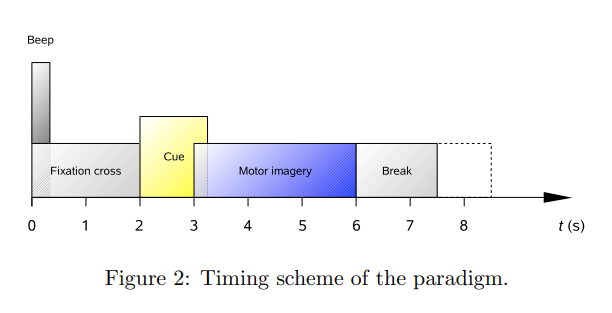

The above is the timing diagram of the experiment. Before the ML pipeline, we shall epoch each of these events, and apply processsing techniques like Common Spatial Pattern (CSP) to obtain numerical features, which will be fed to different classifiers in the pipeline.

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


mne.set_log_level('ERROR')

In [3]:
%matplotlib widget

### Section A - Dataset and EDA

The competition provides two datasets for each subject. In our case there are 9 subject recording, however we shall limit to only using the first subject's data for this track. One dataset is supposed to be trained on fully, and should be tested on the evaluataion dataset.

##### A1 - Dataset Loading and Audit

In [4]:
raw_train_1 = mne.io.read_raw_gdf("../datasets/A01T.gdf")
raw_eval_1 = mne.io.read_raw_gdf("../datasets/A01E.gdf")

In [5]:
eog_chs = raw_train_1.ch_names[-3:] 
raw_train_1.set_channel_types({ch: 'eog' for ch in eog_chs})

eog_chs_eval = raw_eval_1.ch_names[-3:]
raw_eval_1.set_channel_types({ch: 'eog' for ch in eog_chs_eval})


ch_names_2a = ['Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz',
               'C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz',
               'P2','POz','EOG-left','EOG-central','EOG-right']
raw_train_1.rename_channels(dict(zip(raw_train_1.ch_names, ch_names_2a)))
raw_eval_1.rename_channels(dict(zip(raw_eval_1.ch_names, ch_names_2a)))

raw_train_1.set_montage(mne.channels.make_standard_montage('standard_1020'),
                           match_case=False, on_missing='ignore')
raw_eval_1.set_montage(mne.channels.make_standard_montage('standard_1020'),
                           match_case=False, on_missing='ignore')

<RawGDF | A01E.gdf, 25 x 687000 (2748.0 s), ~33 KiB, data not loaded>

In [6]:
raw_train_1

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~33 KiB, data not loaded>

In [7]:
raw_eval_1

<RawGDF | A01E.gdf, 25 x 687000 (2748.0 s), ~33 KiB, data not loaded>

In [8]:
raw_train_1.load_data()

raw_train_1.notch_filter(freqs=[50, 100], picks='eeg', verbose=False)

raw_train_1.filter(l_freq=1, h_freq=40, picks='eeg', verbose=False)

print("Preprocessing applied:", raw_train_1.info['highpass'], "-", raw_train_1.info['lowpass'], "Hz")
print("Reference:", raw_train_1.info['custom_ref_applied'])

Preprocessing applied: 1.0 - 40.0 Hz
Reference: 0 (FIFFV_MNE_CUSTOM_REF_OFF)


In [9]:
events, event_id = mne.events_from_annotations(raw_train_1, verbose=False)

marker_label = {
    1: "Rejected Trial",
    2: "Eye movments",
    3: "Idling EEG (eyes open)",
    4: "Idling EEG (eyes closed)",
    5: "Start of a new run",
    6: "Start of a trial",
    7: "left_hand",
    8: "right_hand",
    9: "feet",
    10: "tongue",
}

mi_event_id = {marker_label[v]: v for k, v in event_id.items()
               if marker_label[v] in ['left_hand', 'right_hand', 'feet', 'tongue']}

mi_epochs = mne.Epochs(raw_train_1, events, event_id=mi_event_id,
                        tmin=-0.5, tmax=5.25, baseline=None, preload=True)

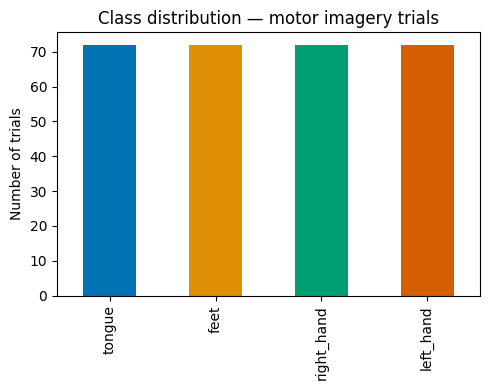

In [10]:
class_counts = pd.Series(mi_epochs.events[:, -1]).map(
    {v: k for k, v in mi_event_id.items()}
).value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', ax=ax, color=sns.color_palette('colorblind'))
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution — motor imagery trials")
plt.tight_layout()
plt.show()

##### A2 - EDA Visualization

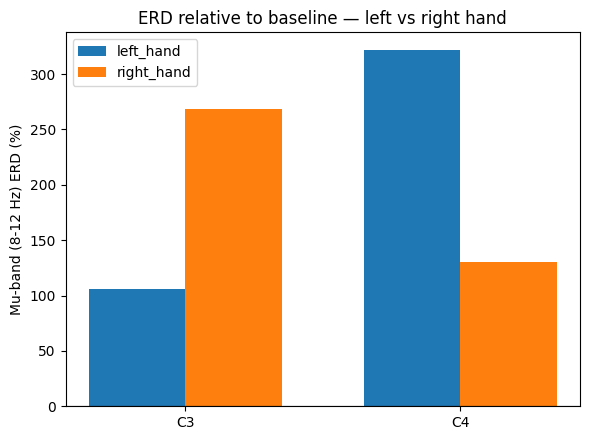

    left_hand_mean_ERD%  right_hand_mean_ERD%
C3           106.271853            268.737933
C4           321.553464            129.821592


In [11]:
def compute_erd_percent(epochs, condition, channel, fmin=8, fmax=12,
                         baseline_window=(-0.5, 0), task_window=(0.5, 4.0)):
    ep = epochs[condition].copy()
    ch_idx = ep.ch_names.index(channel)

    base = ep.copy().crop(*baseline_window)
    task = ep.copy().crop(*task_window)

    psd_base = base.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                                 picks=[ch_idx], verbose=False).get_data().squeeze(axis=1)
    psd_task = task.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                                 picks=[ch_idx], verbose=False).get_data().squeeze(axis=1)

    # mean power per trial across the freq band, then % change vs baseline
    base_power = psd_base.mean(axis=1)
    task_power = psd_task.mean(axis=1)
    erd_pct = 100 * (task_power - base_power) / base_power
    return erd_pct  # one value per trial

fig, ax = plt.subplots(figsize=(6, 4.5))
results = {}
for cls, color in zip(['left_hand', 'right_hand'], ['tab:blue', 'tab:orange']):
    for channel in ['C3', 'C4']:
        erd = compute_erd_percent(mi_epochs, cls, channel)
        results[(cls, channel)] = erd

labels = ['C3', 'C4']
x = np.arange(len(labels))
width = 0.35

left_means = [results[('left_hand', ch)].mean() for ch in labels]
right_means = [results[('right_hand', ch)].mean() for ch in labels]

ax.bar(x - width/2, left_means, width, label='left_hand')
ax.bar(x + width/2, right_means, width, label='right_hand')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mu-band (8-12 Hz) ERD (%)")
ax.set_title("ERD relative to baseline — left vs right hand")
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({f"{cls}_mean_ERD%": [results[(cls, ch)].mean() for ch in labels]
                     for cls in ['left_hand', 'right_hand']}, index=labels))

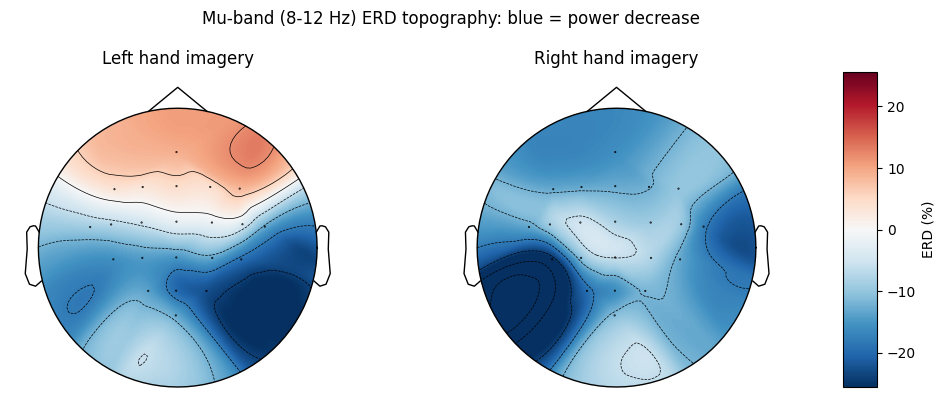

In [12]:
epochs_topo = mi_epochs.copy().pick_types(eeg=True)
montage = mne.channels.make_standard_montage('standard_1020')
epochs_topo.set_montage(montage, match_case=False, on_missing='ignore')

def compute_erd_percent_all_channels(epochs, condition, fmin=8, fmax=12,
                                      baseline_window=(-0.5, 0), task_window=(0.5, 4.0)):
    ep = epochs[condition].copy()
    base = ep.copy().crop(*baseline_window)
    task = ep.copy().crop(*task_window)

    psd_base = base.compute_psd(method='welch', fmin=fmin, fmax=fmax, verbose=False).get_data()
    psd_task = task.compute_psd(method='welch', fmin=fmin, fmax=fmax, verbose=False).get_data()

    # average over freq bins, then over trials -> one value per channel
    base_power = psd_base.mean(axis=2).mean(axis=0)  # (n_channels,)
    task_power = psd_task.mean(axis=2).mean(axis=0)
    erd_pct = 100 * (task_power - base_power) / base_power
    return erd_pct

erd_left = compute_erd_percent_all_channels(epochs_topo, 'left_hand')
erd_right = compute_erd_percent_all_channels(epochs_topo, 'right_hand')

vlim = max(np.abs(erd_left).max(), np.abs(erd_right).max())

fig, axes = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1, 0.08]})

im, _ = mne.viz.plot_topomap(erd_left, epochs_topo.info, axes=axes[0], show=False,
                              cmap='RdBu_r', vlim=(-vlim, vlim))
axes[0].set_title('Left hand imagery')

im, _ = mne.viz.plot_topomap(erd_right, epochs_topo.info, axes=axes[1], show=False,
                              cmap='RdBu_r', vlim=(-vlim, vlim))
axes[1].set_title('Right hand imagery')

norm = plt.Normalize(vmin=-vlim, vmax=vlim)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
fig.colorbar(sm, cax=axes[2], label='ERD (%)')

fig.suptitle('Mu-band (8-12 Hz) ERD topography: blue = power decrease')
plt.tight_layout()
plt.show()

### Section B - Preprocessing and Feature Engineering

In this section, we shall see how we derive a tabular dataset from the given time series data. Earlier we had epoched the entire timeseries into 72 epochs for each classes (left, right, foot, tongue). Each of those epochs last for over 7 seconds, sampled at 250Hz. Our goal on the following cells is to convert these time series into a feature vectors. We shall employ CSP. CSP essentially computes the spatial covariance matrices (22 x 22 here) for every point in time in the poch, and averages those covariance matrices. 

Similar to LDA, we find two eigen vectors, maximising one class over minimizing the other class. These eigenvectors are used to project to derive the feature vectors.

##### Feature Extraction from Time Series

In [13]:
from mne.decoding import CSP

raw_csp = raw_train_1.copy().filter(l_freq=8, h_freq=30, picks='eeg', verbose=False)
epochs_csp = mne.Epochs(raw_csp, events, event_id=mi_event_id,
                         tmin=-0.5, tmax=5.25, baseline=None, preload=True, verbose=False)
epochs_csp.pick_types(eeg=True)
epochs_csp_crop = epochs_csp.copy().crop(tmin=0.5, tmax=4.0)

X_all = epochs_csp_crop.get_data()      # (n_trials, n_channels, n_times)
y_all = epochs_csp_crop.events[:, -1]   # event codes

class_codes = {cls: mi_event_id[cls] for cls in ['left_hand', 'right_hand', 'feet', 'tongue']}

ovr_features = []
fitted_csps = {}

for cls, code in class_codes.items():
    y_binary = (y_all == code).astype(int)
    csp_cls = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
    features = csp_cls.fit_transform(X_all, y_binary)
    ovr_features.append(features)
    fitted_csps[cls] = csp_cls

X_features = np.hstack(ovr_features)  # (n_trials, 16) — 4 classes x 4 components
y_labels = y_all    

feature_names = [f"{cls}_csp{i}" for cls in class_codes for i in range(4)]
df_features = pd.DataFrame(X_features, columns=feature_names)
df_features['label'] = pd.Series(y_labels).map({v: k for k, v in class_codes.items()})

print("CSP feature matrix shape:", X_features.shape)
df_features.head()

CSP feature matrix shape: (288, 16)


,left_hand_csp0,left_hand_csp1,left_hand_csp2,left_hand_csp3,right_hand_csp0,right_hand_csp1,right_hand_csp2,right_hand_csp3,feet_csp0,feet_csp1,feet_csp2,feet_csp3,tongue_csp0,tongue_csp1,tongue_csp2,tongue_csp3,label
0,-0.014977,-0.086175,-0.072868,0.034101,0.213856,-0.001255,-0.016424,-0.083414,-0.427607,-0.489305,-0.398702,-0.385515,-0.234671,-0.471003,-0.452465,-0.378019,tongue
1,0.071896,0.127261,-0.187155,-0.218177,-0.178699,0.010313,0.024996,0.049093,-0.145242,-0.237909,-0.422956,-0.413327,-0.707867,-0.486661,-0.440091,-0.349392,feet
2,-1.208925,-0.911184,-1.663704,-1.799577,-1.875797,-1.505914,-1.169659,-1.084304,-1.075787,-1.774633,-1.468489,-1.931949,-2.216822,-1.693925,-1.937201,-1.408809,right_hand
3,-1.605222,-1.266470,-0.171332,-0.307698,0.033006,-0.057759,-1.616645,-1.177553,-1.554493,-0.890169,-1.379875,-0.389904,-0.548044,-1.201808,-0.781770,-1.537841,left_hand
4,-1.196193,-1.141746,-0.325353,-0.195094,-0.080255,-0.079471,-1.092854,-1.216365,-1.353187,-0.801290,-0.983567,-0.638277,-0.699238,-1.218146,-0.677201,-1.318576,left_hand


PCA on derived feature vectors

Explained variance ratio: [0.85242432 0.09473215]
Total variance captured: 0.9471564634237957


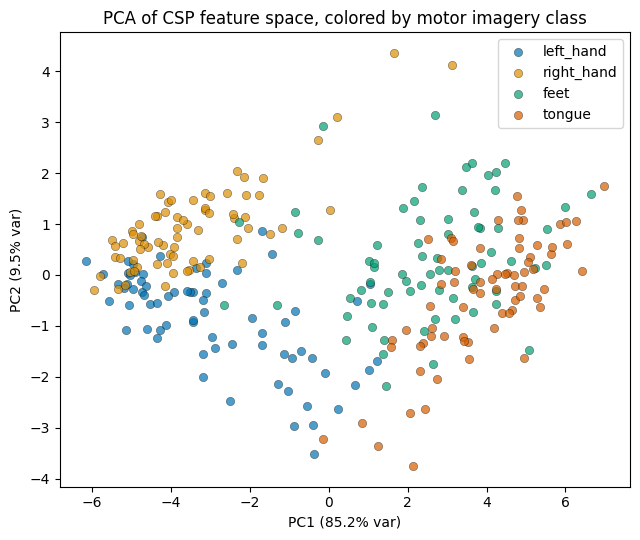

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_features)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
labels_readable = df_features['label']
colors = sns.color_palette('colorblind', n_colors=4)

for cls, color in zip(class_codes.keys(), colors):
    mask = labels_readable == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, color=color, alpha=0.7, edgecolor='k', linewidth=0.3)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA of CSP feature space, colored by motor imagery class")
ax.legend()
plt.tight_layout()
plt.show()

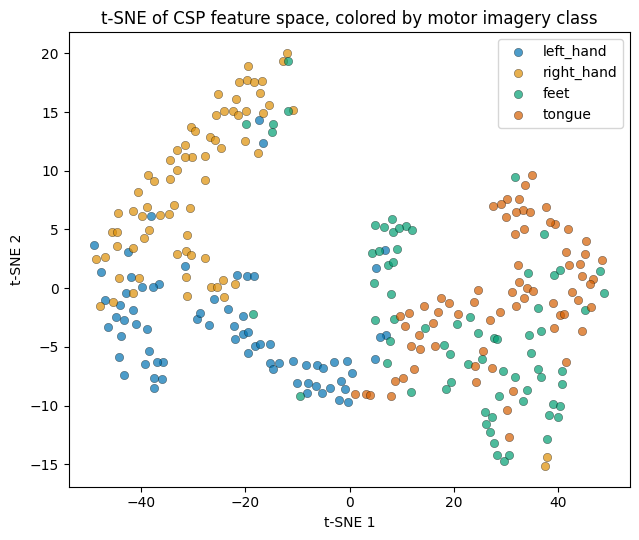

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_scaled)  # reuse the same scaled CSP features as PCA

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cls, color in zip(class_codes.keys(), colors):
    mask = labels_readable == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=cls, color=color, alpha=0.7, edgecolor='k', linewidth=0.3)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE of CSP feature space, colored by motor imagery class")
ax.legend()
plt.tight_layout()
plt.show()

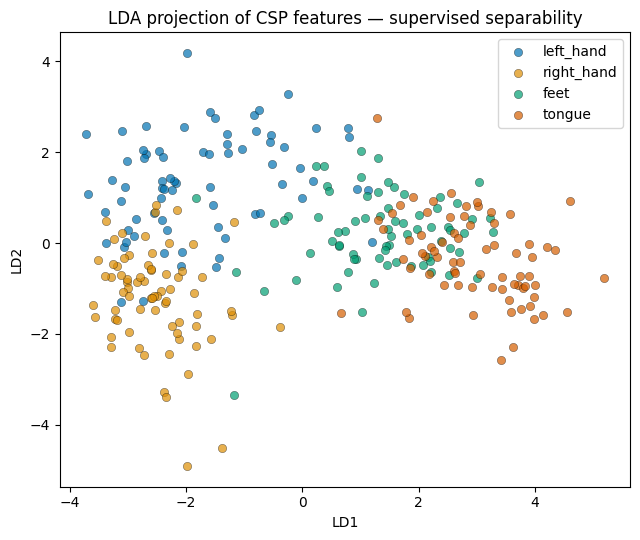

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_viz = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda_viz.fit_transform(X_scaled, y_labels)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cls, color in zip(class_codes.keys(), colors):
    mask = labels_readable == cls
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], label=cls, color=color, alpha=0.7, edgecolor='k', linewidth=0.3)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_title("LDA projection of CSP features — supervised separability")
ax.legend()
plt.tight_layout()
plt.show()

Explained variance ratio per LD: [0.77354392 0.13310712 0.09334896]


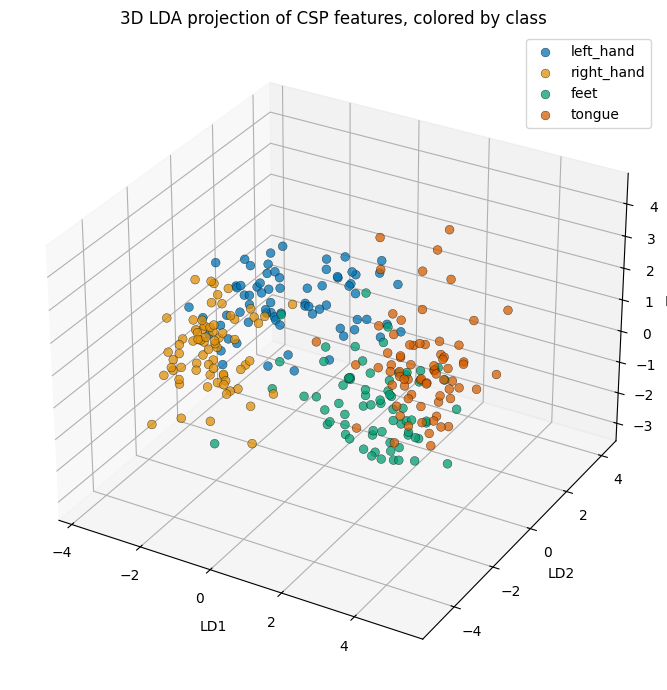

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — required for 3d projection

lda_3d = LinearDiscriminantAnalysis(n_components=3)
X_lda3 = lda_3d.fit_transform(X_scaled, y_labels)

print("Explained variance ratio per LD:", lda_3d.explained_variance_ratio_)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

for cls, color in zip(class_codes.keys(), colors):
    mask = labels_readable == cls
    ax.scatter(X_lda3[mask, 0], X_lda3[mask, 1], X_lda3[mask, 2],
               label=cls, color=color, alpha=0.75, edgecolor='k', linewidth=0.3, s=40)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")
ax.set_title("3D LDA projection of CSP features, colored by class")
ax.legend()
plt.tight_layout()
plt.show()